# Linear Regression

This notebook walks through:

1. Load a scikit-learn dataset with continuous features
2. Fit a **1D** linear regression line using an **exact (closed-form) solver**
3. Compute **L1** and **L2** losses
4. Plot **loss vs. parameter(s)** to see **parabola** behavior.
5. Solve using iterative approach and with **Gradient Descent (GD)** and **SGD**
6. Plot **loss per iteration**.
7. Using sklearn built-in functions **LinearRegression** and **SGDRegressor**.
8. Fit **multidimentional** regression model and SGD on multidimensional data.
9. Visualize **2D feature space** against the target.


In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, SGDRegressor

SEED = 2026
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 5)


## Dataset

We use diabetes dataset from scikit-learn and try to predict the progression of the disease.


In [2]:
# 1) Load a dataset with continuous, standardized features
diabetes = load_diabetes()

# You can see the description of data using print(diabetes.DESCR)
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
# The two important attributes from this dataset we need to use are .data and .target
X = diabetes.data
y = diabetes.target.astype(float)
# The features are already standardized.
# Instead of scaling the column to std = 1, they have a sum of squres = 1
print(f"Is mean = 0 for all columns? {np.allclose(X.mean(axis=0), 0)}")
print(f"Is the SS = 1 for all columns? {np.allclose(np.sum(np.square(X), axis=0), 1)}")

feature_names = diabetes.feature_names
n, p = X.shape
print(f"dimensions (n, p): {n, p}")
print(f"{feature_names=}")

Is mean = 0 for all columns? True
Is the SS = 1 for all columns? True
dimensions (n, p): (442, 10)
feature_names=['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Using Closed Form Solution

For a dataset with **n** examples and **p** features:

- Design matrix: $X \in \mathbb{R}^{n \times p}$
- Targets: $y \in \mathbb{R}^{n}$
- Linear model (with intercept):
  $$\hat y = Xw + b$$
  where $w \in \mathbb{R}^{p}$ and $b \in \mathbb{R}$.

Here is our process of predicting y from one of the features.

- Pick any feature (we pick "bmi").
- Absorb $b$ into the feature matrix and call the result design matrix.
- Use the following equation to solve for W.
- The first element of W is our biases and the second column is the weights between feature and target.

$$\mathbf{w} = (X^\top X)^{-1}X^\top \mathbf{y}$$


In [4]:
# Choose one feature (e.g., BMI) and create a 1D design matrix.
j = feature_names.index("bmi")
x = X[:, j]

# Adding the intercept (column of 1s) to the X matrix.
X_design = np.column_stack([np.ones(n), x])

XtX = X_design.T @ X_design
invert = np.linalg.inv(XtX)
w = invert @ X_design.T @ y

# The first value is bias and the second one is the weight
print(f"b={w[0]:.3f} and weight={w[1]:.3f}")


b=152.133 and weight=949.435


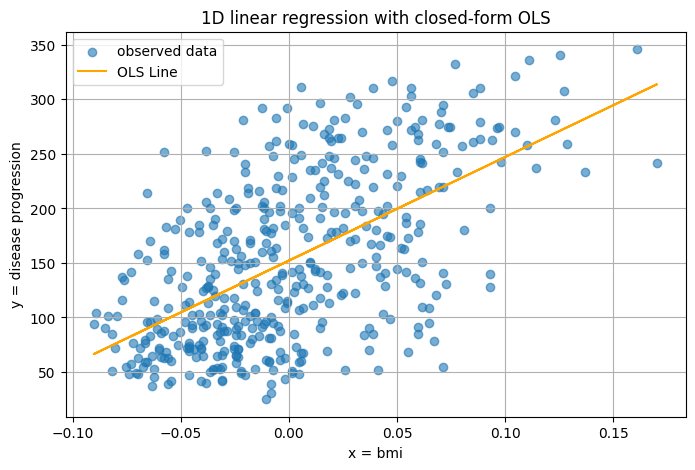

In [5]:
# Plot the data and fitted line

# Getting the predicted target values
y_hat = X_design @ w

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.6, label="observed data")
ax.plot(x, y_hat, color="orange", label="OLS Line")
ax.set_xlabel(f"x = {feature_names[j]}")
ax.set_ylabel("y = disease progression")
ax.set_title("1D linear regression with closed-form OLS")
ax.legend()
ax.grid(True)
plt.show()

## Loss Function

Compute L1 and L2 loss (for this fitted line)

$$\mathcal{L}_1 = \sum_i |y_i - \hat y_i|$$
$$\mathcal{L}_2 = \sum_i (y_i - \hat y_i)^2$$


In [6]:
residual = y - y_hat

L1 = np.sum(np.abs(residual))
L2 = np.sum(residual**2)

print(f"L1 loss = {L1:.3f}")
print(f"L2 loss = {L2:.3f}")

L1 loss = 22894.993
L2 loss = 1719581.811


We can visualize the shape of L2 loss function against some hypothetical w values. To do this:

- We first create these w values around the computed w_hat
- Then compute y_hat and residual with respect to these w_hat values and x.

_Note that we only plot L2 loss because **OLS optimizes L2 Loss** and not the L1 loss. Notice that the actual computed $\hat{w}$ is the minimum of the L2 function_


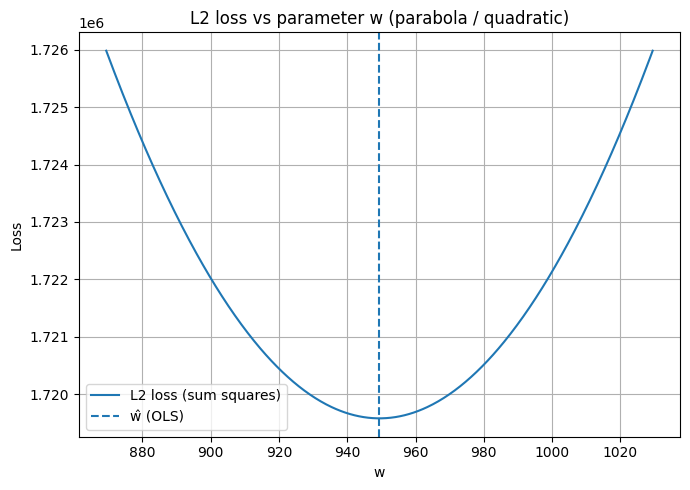

In [7]:
# Sweep w around the OLS solution and compute L2
b = w[0]
w_grid = np.linspace(w[1] - 80, w[1] + 80, 600)

L2_grid = []
for weight in w_grid:
    y_hat = weight * x + b
    r = y - y_hat
    L2_grid.append(np.sum(r**2))

L2_grid = np.array(L2_grid)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(w_grid, L2_grid, label="L2 loss (sum squares)")
ax.set_title("L2 loss vs parameter w (parabola / quadratic)")
ax.axvline(w[1], linestyle="--", label="ŵ (OLS)")
ax.set_xlabel("w")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

## Using Iterative Approach

### Gradient Descent

Once we define our L2 loss function. We can compute the gradient of the loss w.r.t. $w$ using the following.

$$\nabla_w L(w) = -\frac{2}{n} X^\top (y - \hat{y})$$

Then we can use the gradient in Gradient Descent update rule using:

$$w^{(t+1)} = w^{(t)} - \eta \nabla_w L(w^{(t)})$$

Remember that in the iterative approach we first have to initiate our weight vector.


In [8]:
n, p = X_design.shape

# Initialize weights
w = np.zeros(p)

# Hyperparameters
eta = 0.01  # learning rate
n_iter = 200_000  # number of training iterations

# Running the iterations
for _ in range(n_iter):
    y_hat = X_design @ w
    gradient = (-2 / n) * X_design.T @ (y - y_hat)
    w = w - eta * gradient

print("Using gradient descent\n")
print(f"b={w[0]:.3f} and weight={w[1]:.3f}")

Using gradient descent

b=152.133 and weight=949.324


We can compute the L2 loss and compare between the two different methods. You can see that with enough iterations, the two should converge to about the same loss.


In [9]:
y_hat = X_design @ w
residual = y - y_hat
L2_gd = np.sum(residual**2)

print("L2 Losses:")
print(f"Closed form:        {L2:.3f}")
print(f"Gradient descent:   {L2_gd:.3f}")

L2 Losses:
Closed form:        1719581.811
Gradient descent:   1719581.823


### Stochastic Gradient Descent

It is similar to gradient descent described above, but with the following changes:

- Instead of computing gradient on the entire dataset, we sample one datapoint everytime and get the gradient of that.
- We update the weight matrix using the gradient obtained from this single data point every time.

_Note: The previous approach is called **whole-batch gradient** descent. In practice we use an approach in-between stochastic and whole-batch where we pick smaller batches of data for gradient computations._

So mathematically:

$$\nabla_w l(w) = -2 x_i (y_i - \hat{y}_i)$$

$$w^{(t+1)} = w^{(t)} - \eta \nabla_w l(w^{(t)})$$


In [10]:
# Initialize weights
w = np.zeros(p)

# Hyperparameters
eta = 0.01  # learning rate
n_iter = 200_000  # number of training iterations

# Running the iterations
for _ in range(n_iter):
    # Note that we are using a random data-point for both x and y.
    idx = np.random.randint(n)
    x_i = X_design[idx]
    y_i = y[idx]
    y_hat_i = x_i @ w
    # Note that our gradient is also a point-wise gradient.
    gradient = -2 * x_i * (y_i - y_hat_i)
    w = w - eta * gradient

print("Using Stochastic gradient descent:\n")
print(f"b={w[0]:.3f} and weight={w[1]:.3f}")

Using Stochastic gradient descent:

b=145.543 and weight=952.808


## Visualizing Gadient Descent

Here we visualize loss progression over iterations for both gradient descent and stochastic gradient descent.

Although in SGD algorithm, we calculate point-wise loss for updating $w$ in each iteration, in order to do a fair comparison between the two algorithms, we need to calculate the average loss across the entire dataset in each iteration.


In [11]:
def L2_loss(w, X, y):
    """Computes the L2 loss."""
    X = np.atleast_2d(X)
    y = np.atleast_1d(y)

    r = y - X @ w
    return np.mean(r**2)


def grad_L2(w, X, y):
    """
    Computes gradient of L2 loss w.r.t. w and b.
    Works for both bath and single-point gradient
    """
    X = np.atleast_2d(X)
    y = np.atleast_1d(y)
    r = y - X @ w
    return (-2 / len(X)) * X.T @ r

In [12]:
n, p = X_design.shape
# Hyperparameters
eta = 0.01  # learning rate
n_iter = 100  # number of training iterations

## GD
gd_losses = []

# Initialize weights
w_gd = np.zeros(p)
w_path_gd = []

# Running GD
for _ in range(n_iter):
    w_path_gd.append(w_gd.copy())
    loss = L2_loss(w_gd, X_design, y)
    gd_losses.append(loss)
    gradient = grad_L2(w_gd, X_design, y)
    w_gd -= eta * gradient

w_path_gd = np.array(w_path_gd)

## SGD
sgd_losses = []

# Initialize weights
w_sgd = np.zeros(p)
w_path_sgd = []

for _ in range(n_iter):
    w_path_sgd.append(w_sgd.copy())
    idx = np.random.randint(n)
    x_i = X_design[idx]
    y_i = y[idx]

    # Computing full-dataset loss
    full_loss = L2_loss(w_sgd, X_design, y)
    sgd_losses.append(full_loss)

    # But we still use point-wise computation for updating weights.
    gradient = grad_L2(w_sgd, x_i, y_i)
    w_sgd -= eta * gradient

w_path_sgd = np.array(w_path_sgd)

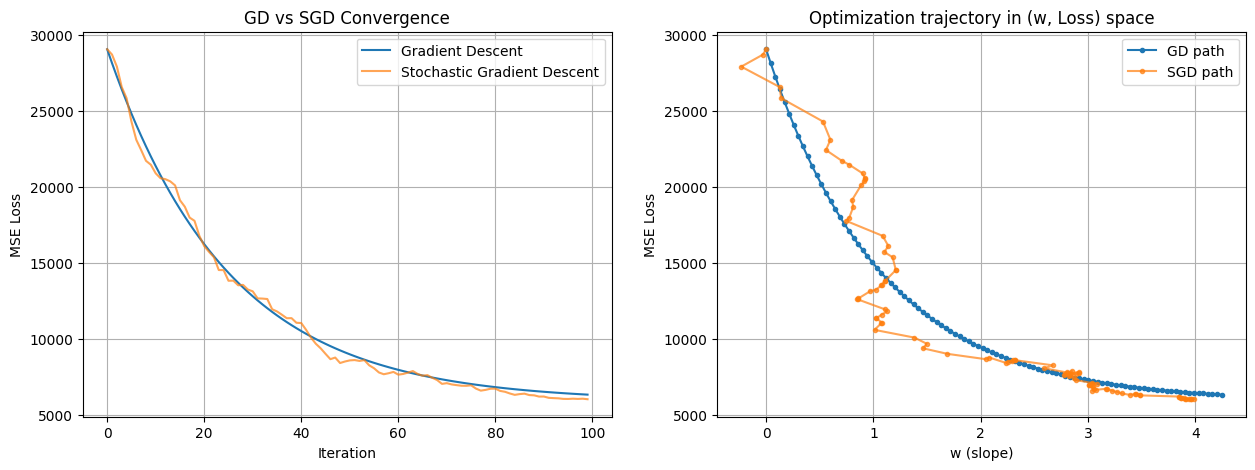

In [13]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))

axes[0].plot(gd_losses, label="Gradient Descent")
axes[0].plot(sgd_losses, label="Stochastic Gradient Descent", alpha=0.7)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("GD vs SGD Convergence")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(w_path_gd[:, 1], gd_losses, marker="o", markersize=3, label="GD path")
axes[1].plot(
    w_path_sgd[:, 1], sgd_losses, marker="o", markersize=3, alpha=0.7, label="SGD path"
)
axes[1].set_xlabel("w (slope)")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Optimization trajectory in (w, Loss) space")
axes[1].legend()
axes[1].grid(True)

plt.show()

## Using sklearn built-in functions

`scikit-learn` provides two methods for computing regression lines using closed-form as well as using the iterative approach.

- The `LinearRegression` solves linear problems using an approach similar to our closed-form approach (although a bit more mathematically involved).
- The `SGDRegressor` used Stochastic gradient descent pretty much the same way we discussed. This regressor also provides a regularized term.

We use these pretty much the same way we use any other sklearn function class.

- Create a class instance with given parametes.
- Fit using your data.
- Predict and calcuate metrics.


In [14]:
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Note after fitting the model, we can access intercept and weights using `intercept_` and `coef_`.


In [15]:
lr = LinearRegression(fit_intercept=True)

lr.fit(X, y)

print(f"Intercept = {lr.intercept_}\n")
print("Weights:\n")
print(pd.Series(lr.coef_, index=lr.feature_names_in_))

y_hat = lr.predict(X)
L2_loss = np.mean((y - y_hat) ** 2)
print("\n")
print(f"L2 Loss = {L2_loss:.3f}")

Intercept = 152.13348416289597

Weights:

age    -10.009866
sex   -239.815644
bmi    519.845920
bp     324.384646
s1    -792.175639
s2     476.739021
s3     101.043268
s4     177.063238
s5     751.273700
s6      67.626692
dtype: float64


L2 Loss = 2859.696


In [16]:
# Note that we have many more hyperparameters than LinearRegression.
# Also note that we can define a penalty term (default value is L2)
# And the existence of max_iter, random_state, and learning_rate tells us this is an iterative approach.

sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    # alpha=0.0001,
    fit_intercept=True,
    max_iter=10_000,
    random_state=SEED,
    eta0=0.01,
    learning_rate="adaptive",
    validation_fraction=0.1,
)

sgd.fit(X, y)

print(f"Intercept = {sgd.intercept_}\n")
print("Weights:\n")
print(pd.Series(sgd.coef_, index=sgd.feature_names_in_))

y_hat = sgd.predict(X)
L2_loss = np.mean((y - y_hat) ** 2)
print("\n")
print(f"L2 Loss = {L2_loss:.3f}")

Intercept = [152.13531935]

Weights:

age      7.513830
sex   -195.088104
bmi    484.760419
bp     301.322672
s1     -40.591303
s2    -105.063571
s3    -206.956457
s4     128.364058
s5     405.065240
s6     118.491338
dtype: float64


L2 Loss = 2901.070


## Visualizing 2-D Regression

Here we will attempt to visualize data and fitted regression plane on 2 features. For this example we will be using `LinearRegression`.


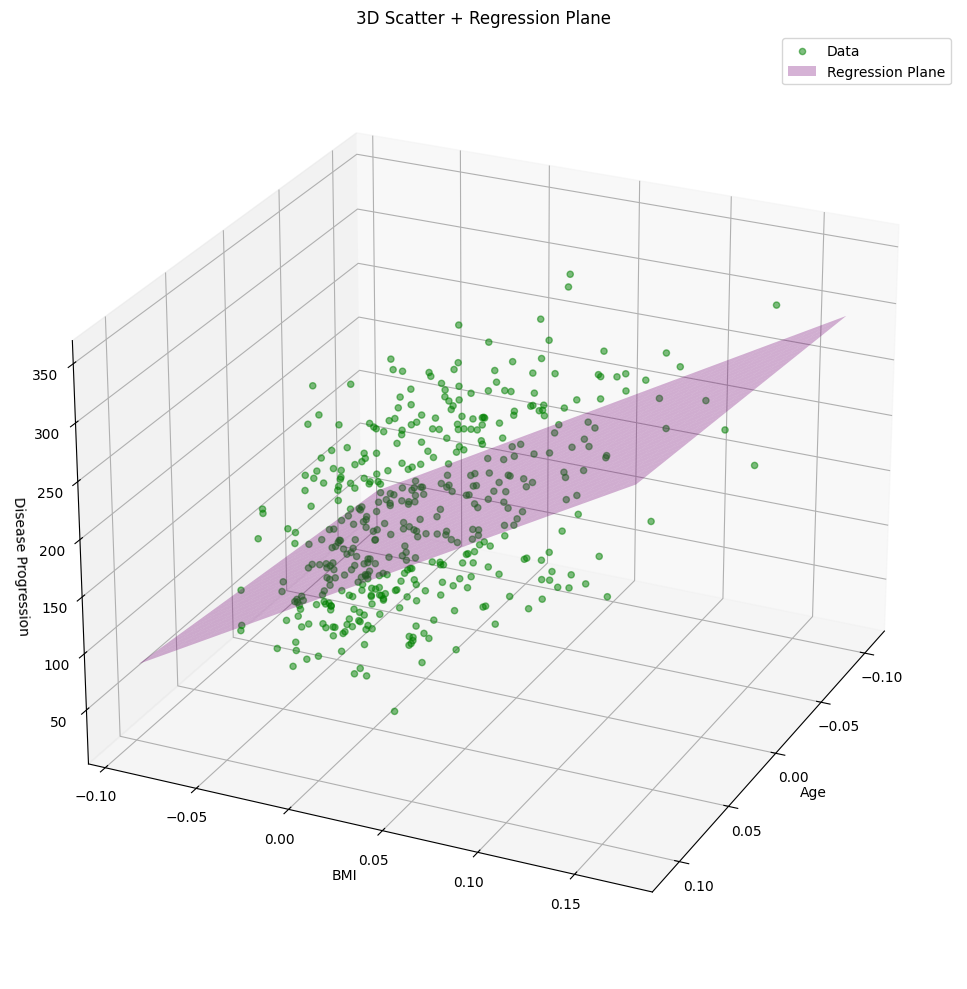

In [17]:
X = diabetes.data
y = diabetes.target

# Pick two features
x0 = X[:, 0]  # Age
x1 = X[:, 2]  # BMI

X_2d = np.column_stack([x0, x1])

# Fit linear regression using 2 features
lr = LinearRegression(fit_intercept=True)
lr.fit(X_2d, y)

b = lr.intercept_
w0, w1 = lr.coef_


# Create a meshgrid over x0 and x1
x0_grid = np.linspace(x0.min(), x0.max(), 30)
x1_grid = np.linspace(x1.min(), x1.max(), 30)
xx0, xx1 = np.meshgrid(x0_grid, x1_grid)

# Regression plane values
yy_hat = w0 * xx0 + w1 * xx1 + b

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")
ax.scatter(x0, x1, y, alpha=0.5, color="green", label="Data")
ax.plot_surface(xx0, xx1, yy_hat, alpha=0.3, color="purple", label="Regression Plane")
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_zlabel("Disease Progression")
ax.set_title("3D Scatter + Regression Plane")
ax.legend()
ax.view_init(elev=25, azim=25)  # Adjusts the viewing angle.

plt.tight_layout()
plt.show()

## Summary

- Closed-form OLS gives an exact solution (when feasible) but can become expensive as feature dimension \(p\) grows.
- GD/SGD avoid matrix inversion; they can scale better to large \(p\) and large \(n\), but require:
  - learning rate tuning,
  - iteration budgeting,
  - and careful monitoring of convergence.

You now have:

- L1 vs L2 loss curves (V-shape vs parabola)
- Closed-form OLS solutions (1D and multi-D)
- Loss vs parameter(s) plots (contours / surfaces)
- GD/SGD implementations from scratch
- Loss vs iterations plots
- Built-in methods for regression and sgd in sklearn
